# Стационарность и автокорреляция

## Подготовка

In [1]:
# Работа с данными
import pandas as pd
import numpy as np
import requests

# Визуализации
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Анализ автокорреляции
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Модели ARMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL, MSTL

# import warnings
# warnings.filterwarnings("ignore")

# Для воспроизводимости
np.random.seed(42)


ImportError: cannot import name 'MSTL' from 'statsmodels.tsa.seasonal' (C:\Users\n.osipov\Anaconda3_new\lib\site-packages\statsmodels\tsa\seasonal.py)

In [ ]:
def adf_test(timeseries, maxlag=None):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", maxlag=maxlag)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "# Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

## Стационарность

😻 **Что требуется для стационарности?**

**Сильная и слабая стационарность**

**Сильная (=строгая) стационарность** означает, что при сдвиге во времени не меняется **всё совместное распределение** ряда. Для любых моментов времени $t_1, \ldots, t_k$ и любого сдвига $h$:

$$
(y_{t_1}, \ldots, y_{t_k}) \overset{d}{=} (y_{t_1+h}, \ldots, y_{t_k+h}).
$$

Иными словами, во времени стабильны не только среднее и дисперсия, но и форма распределения, его хвосты, асимметрия и структура зависимостей.

**Слабая стационарность** требует только стабильности среднего, дисперсии и автоковариации:

$$
E(y_t)=\mu, \qquad Var(y_t)=\sigma^2, \qquad Cov(y_t, y_{t-k})=\gamma(k).
$$

Среднее и дисперсия не зависят от времени, а ковариация зависит только от лага $k$, но не от конкретного момента $t$.

Важно: слабая стационарность **не означает**, что распределение обязательно меняется. Она просто не требует, чтобы оно целиком оставалось неизменным. Сильно стационарный ряд с конечной дисперсией является и слабо стационарным, но не наоборот.


**Зачем нужна стационарность?** Многие модели предполагают, что закономерности, найденные в прошлом, сохраняются в будущем. При стационарности можно оценивать одно среднее, одну дисперсию и автокорреляции для всего ряда, интерпретировать параметры модели и использовать их для прогноза. Для большинства классических моделей временных рядов достаточно **слабой стационарности**. Поэтому, если не сказано иное, под «стационарным временным рядом» обычно понимают именно слабо стационарный ряд.

**Визуализируем разницу**

На каждом кадре ниже показано распределение значений среди множества независимых реализаций в момент $t$.

- Слева распределение всегда одно и то же: процесс сильно (и одновременно слабо) стационарен.
- Справа распределение чередуется между нормальным и двухточечным, но $E(y_t)=0$, $Var(y_t)=1$, а автоковариация при ненулевых лагах равна нулю. Поэтому процесс слабо стационарен, но не сильно стационарен.


In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage, display

rng_stationarity = np.random.default_rng(42)
n_frames = 16 # в рядах будет по 16 точек
n_realizations = 600 # генерируем 600 реализаций одного процесса - для визуализации распределений

# Сильно стационарный процесс: распределение одинаково для всех t
strong_stationary = rng_stationarity.normal(size=(n_frames, n_realizations))

# Слабо, но не сильно стационарный процесс:
# распределение меняется, а среднее и дисперсия остаются равны 0 и 1
weak_stationary = np.empty((n_frames, n_realizations))
for t in range(n_frames):
    if t % 2 == 0:
        weak_stationary[t] = rng_stationarity.normal(size=n_realizations)
    else:
        weak_stationary[t] = rng_stationarity.choice([-1, 1], size=n_realizations)

bins = np.linspace(-3.5, 3.5, 29)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

def draw_frame(t):
    for ax in axes:
        ax.clear()
        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(0, 2.2)
        ax.set_xlabel(r"$y_t$")
        ax.set_ylabel("Плотность")
        ax.grid(alpha=0.2)

    axes[0].hist(
        strong_stationary[t], bins=bins, density=True,
        color="royalblue", edgecolor="white"
    )
    axes[0].set_title("Сильная стационарность\n" + r"$y_t \sim N(0, 1)$")

    axes[1].hist(
        weak_stationary[t], bins=bins, density=True,
        color="darkorange", edgecolor="white"
    )
    distribution = (
        r"$y_t \sim N(0, 1)$"
        if t % 2 == 0
        else r"$P(y_t=-1)=P(y_t=1)=0.5$"
    )
    axes[1].set_title("Слабая, но не сильная стационарность\n" + distribution)

    fig.suptitle(
        rf"Момент $t={t}$: в обоих случаях $E(y_t)=0$ и $Var(y_t)=1$",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.88])

stationarity_animation = FuncAnimation(
    fig, draw_frame, frames=n_frames, interval=700
)
gif_file = "strong_vs_weak_stationarity.gif"
stationarity_animation.save(gif_file, writer=PillowWriter(fps=2))
plt.close(fig)

display(IPImage(filename=gif_file))


### Данные

Далее мы будем работать с сгенерированным стационарным рядом.


In [ ]:
super_stationary = [np.random.normal(0, np.sqrt(1 / (1 - 0.5**2)))]

# Генерируем 400 значений и отбрасываем первые 100
for i in range(1, 400):
    super_stationary.append(
        0.5 * super_stationary[i-1] + np.random.normal(loc=0, scale=1)
    )

super_stationary = super_stationary[100:]


In [ ]:
ss_df = pd.DataFrame(super_stationary)
ss_df.columns = ['y']
ss_df.head()

### Графики

Построим график нашего ряда.

In [ ]:
fig = px.line(ss_df, x=ss_df.index, y=ss_df['y'],
              title="Stationary ts")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="t")
fig.update_yaxes(title_text="y")
fig.show()

Слабая стационарность означает постоянные среднее и дисперсию, а также автоковариацию, которая зависит от лага, но не от момента времени. Попробуем визуализировать среднее и дисперсию с помощью скользящего окна.


In [ ]:
window_size = 10

fig = px.line(title="Stationary ts")
fig.add_scatter(x=ss_df.index, y=ss_df['y'], mode='lines', name='Original y', line=dict(color='silver'))
fig.add_scatter(x=ss_df.index, y=ss_df['y'].rolling(window_size).mean(), mode='lines', name='mean', line=dict(color='red'))
fig.add_scatter(x=ss_df.index, y=ss_df['y'].rolling(window_size).var(ddof=1), mode='lines', name='variance', line=dict(color='blue'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="t")
fig.update_yaxes(title_text="y")
fig.show()


Может показаться, что среднее и дисперсия достаточно сильно меняются во времени. Точно ли наш ряд строго стационарен?

Да, точно :) Процесс, из которого сгенерирован этот ряд, является строго стационарным. Поэтому его теоретическое среднее и дисперсия постоянны. Каждое скользящее окно содержит только 10 случайных и к тому же коррелированных значений. В одном окне случайно может оказаться больше положительных наблюдений, в другом — больше отрицательных или экстремальных. Поэтому оценки заметно колеблются - это обычная случайная изменчивость оценок в коротком окне.


Давайте также посмотрим в динамике на среднее, дисперсию и распределение ряда.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io

# Подготовка ряда
ts = np.array(super_stationary).flatten()
n = len(super_stationary)

min_lim = min(super_stationary)
max_lim = max(super_stationary)

# Параметры окна для визуализации
window = 50
frames = []

for t in range(window, n):
    fig, axes = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios': [2, 1]})

    # Верхний график: ряд и текущее окно
    axes[0].plot(ts, color='lightgray', alpha=0.8)
    axes[0].plot(range(t-window, t), ts[t-window:t], color='royalblue', linewidth=2)
    axes[0].axhline(np.mean(ts[t-window:t]), color='orange', linestyle='--', linewidth=1.5, label='Mean')
    axes[0].set_xlim(0, n)
    axes[0].set_ylim(min_lim, max_lim)
    axes[0].set_title('Stationary Time Series — Moving Window')
    axes[0].legend(loc='upper right', fontsize=8)

    # Нижний график: распределение в текущем окне
    sns.histplot(ts[t-window:t], kde=True, color='royalblue', ax=axes[1])
    axes[1].axvline(np.mean(ts[t-window:t]), color='orange', linestyle='--', linewidth=1.5)
    axes[1].set_xlim(min_lim, max_lim)
    axes[1].set_ylim(0, window//2)
    axes[1].set_title('Distribution in Moving Window')

    plt.tight_layout()

    # Сохраняем кадр в память
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))
    plt.close(fig)

gif_file_2 = "stationary_moving_window.gif"
frames[0].save(
    gif_file_2,
    save_all=True,
    append_images=frames[1:],
    duration=100,  # скорость
    loop=0
)
plt.close(fig)

display(IPImage(filename=gif_file_2))

### Тесты на стационарность

Если бы мы говорили не о сгенерированном, а о реальном ряде, одной визуализации было бы недостаточно для проверки стационарности. Поэтому рассмотрим тесты на стационарность.

😻 **Какие тесты для проверки стационарности использовать?**

In [ ]:
adf_test(ss_df['y'])

В ADF-тесте можно задать параметр *maxlag* — максимальное число лагов разностей, среди которых тест будет выбирать.

В нашей функции задано `autolag="AIC"`, поэтому ADF выбирает число лагов по минимуму AIC (AIC - это информационный критерий Акаике, про него поговорим позже). В примере ниже выбрано 0 дополнительных лагов разностей - см. Lags Used.


In [ ]:
adf_test(ss_df['y'], maxlag=10)

In [ ]:
kpss_test(ss_df['y'])

😻 **Что можно сказать о стационарности на основе результатов тестов?**

## Анализ автокорреляции

Для анализа автокорреляции часто используют функции ACF и PACF.

### ACF

**Автокорреляционная функция (ACF):**

ACF измеряет линейную корреляцию между значениями временного ряда, разделёнными лагом. Она помогает увидеть устойчивую зависимость во времени и сезонные паттерны.

*Основные моменты про ACF:*

* Показывает корреляцию для разных лагов.
* Не исключает связь через промежуточные лаги. Например, ACF на лаге 2 показывает общую связь между $y_t$ и $y_{t-2}$: $y_{t}$ с $y_{t-2}$ напрямую и "косвенную" с $y_{t-1}$.


**Что значит «связь через промежуточные лаги»?**

ACF измеряет общую линейную связь между текущим значением $y_t$ и значением $y_{t-k}$. Она не отделяет связь с конкретным лагом от связи, возникающей через промежуточные значения $y_{t-1}, \ldots, y_{t-k+1}$.

---

**Пример**

Пусть ряд описывается моделью:

$$
y_t = 0.8y_{t-1} + \varepsilon_t.
$$

Отдельного члена $y_{t-2}$ в этой модели нет. Однако предыдущее значение ряда определяется как:

$$
y_{t-1} = 0.8y_{t-2} + \varepsilon_{t-1}.
$$

Подставим второе выражение в первое:

$$
y_t
= 0.8(0.8y_{t-2} + \varepsilon_{t-1}) + \varepsilon_t
= 0.64y_{t-2} + 0.8\varepsilon_{t-1} + \varepsilon_t.
$$

Получается, что $y_t$ и $y_{t-2}$ коррелируют, хотя отдельного члена $y_{t-2}$ в исходной модели нет. Эта связь возникает через промежуточное значение $y_{t-1}$.

В этом примере (т.к. процесс стационарный, 0.8 < 1) ACF(2) = 0.64.

In [ ]:
# Создаём простой временной ряд
np.random.seed(42)
n = 100
ts = np.zeros(n)
for t in range(1, n):
    ts[t] = 0.8 * ts[t-1] + np.random.normal(0, 1) # текущее значение y[t] зависит от предыдущего y[t-1]

# Преобразуем в pandas Series для удобства
ts = pd.Series(ts)
ts.plot()

In [ ]:
# Вычисляем значения ACF
acf_values = acf(ts, nlags=20)  # параметр nlags задаёт число лагов
print("ACF Values:")
print(acf_values)

In [ ]:
# Строим график ACF
plot_acf(np.array(ts), lags = 50)
plt.show()

**График ACF**

*Как интерпретировать:*

* *Медленный спад*: указывает на сильную устойчивость зависимости. Такое бывает и у нестационарных рядов, и у стационарных AR-процессов с коэффициентом, близким к 1, поэтому одного графика недостаточно для вывода о стационарности.
* *Сезонность*: периодические пики могут указывать на сезонность. Например, для месячных данных пики могут появляться на лагах 12, 24 и т.д.
* *Быстрый спад*: означает, что зависимость между далёкими наблюдениями быстро ослабевает.

*Как читать график:*

* *Доверительные интервалы* (по умолчанию 95%) помогают оценить статистическую значимость: значения внутри интервала считаются незначимыми.
* *Значимые значения ACF* (вне интервала) указывают на наличие корреляции на соответствующих лагах.


😻 **Что можно сказать об общей автокорреляции по графику ACF для нашего ряда (см. выше)?**

### PACF

**Частичная автокорреляционная функция (PACF):**

PACF измеряет линейную связь между временным рядом и его значениями с лагами, *исключая линейную связь через промежуточные лаги*.

*Основные моменты про PACF:*

* Убирает линейную связь через промежуточные лаги.
* При лаге $k$ PACF показывает связь между $y_t$ и $y_{t-k}$ при контроле лагов с 1 по $k-1$.


*Что значит «при контроле лагов с 1 по $k-1$»?*

«Контроль» означает, что сначала учитывается линейная связь с промежуточными лагами, а затем оценивается оставшаяся связь между $y_t$ и $y_{t-k}$.

**Пример 1**

$y_t = 0.3 \cdot y_{t-1} + 0.5 \cdot y_{t-2} + \epsilon_t$

Лаги $y_{t-1}$ и $y_{t-2}$ напрямую влияют на $y_t$, потому что оба члена есть в уравнении. Одновременно $y_{t-2}$ влияет на $y_t$ косвенно через $y_{t-1}$, который зависит от $y_{t-2}$ (и $y_{t-3}$).

Поэтому часть корреляции между $y_t$ и $y_{t-2}$ в ACF проходит по косвенному пути: $y_{t-2} \to y_{t-1} \to y_t$.

PACF на лаге измеряет только прямой путь: $y_{t-2} \to y_t$. В данном случае (т.к. процесс стационарный, 0.3+0.5 < 1) PACF(2) = 0.5.

---

**Пример 2**

Вспомним пример с ACF.
Пусть ряд описывается моделью:

$$
y_t = 0.8y_{t-1} + \varepsilon_t.
$$

Отдельного члена $y_{t-2}$ в этой модели нет. Однако предыдущее значение ряда определяется как:

$$
y_{t-1} = 0.8y_{t-2} + \varepsilon_{t-1}.
$$

Подставим второе выражение в первое:

$$
y_t
= 0.8(0.8y_{t-2} + \varepsilon_{t-1}) + \varepsilon_t
= 0.64y_{t-2} + 0.8\varepsilon_{t-1} + \varepsilon_t.
$$

Получается, что $y_t$ и $y_{t-2}$ коррелируют, хотя отдельного члена $y_{t-2}$ в исходной модели нет. Эта связь возникает через промежуточное значение $y_{t-1}$.

* **ACF(2)** показывает общую корреляцию между $y_t$ и $y_{t-2}$, включая связь через $y_{t-1}$.
* **PACF(2)** показывает оставшуюся линейную связь между $y_t$ и $y_{t-2}$ после учёта $y_{t-1}$.

Для такого процесса AR(1) теоретическая PACF на лаге 2 равна нулю, поскольку вся связь между $y_t$ и $y_{t-2}$ объясняется промежуточным лагом $y_{t-1}$.


In [ ]:
# Вычисляем значения PACF
pacf_values = pacf(ts, nlags=20)  # параметр nlags задаёт число лагов
print("PACF Values:")
print(pacf_values)

In [ ]:
# Строим график PACF
plot_pacf(np.array(ts), lags = 40)
plt.show()

**График PACF**

*Как интерпретировать:*

* *Значимые пики на первых лагах*: подсказывают, что ряд может описываться авторегрессионным процессом соответствующего порядка (обсудим позже).
* *Сезонность*: регулярные пики могут указывать на сезонность.
* *Быстрый спад*: означает, что линейную зависимость в основном объясняют первые лаги.

*Как читать график:*

* Значимые значения PACF показывают связь с отдельными лагами после учёта промежуточных лагов.
* Как и в ACF, значения внутри доверительных интервалов статистически незначимы.


😻 **Что можно сказать о полной и частичной автокорреляции по графикам ACF и PACF для нашего ряда (см. выше)?**

### Тест Льюнга–Бокса

На прошлом занятии мы рассмотрели тест Льюнга–Бокса для анализа временных рядов на автокорреляцию.

In [ ]:
acorr_ljungbox(ts, return_df=True)

😻 **Что можно сказать об автокорреляции на основе теста Льюнга–Бокса?**

*В чём разница между ACF, PACF и тестом Льюнга–Бокса?*

* ACF показывает корреляцию отдельно для каждого лага.
* PACF показывает корреляцию с каждым лагом после учёта промежуточных лагов.
* Тест Льюнга–Бокса проверяет совместную гипотезу: равны ли нулю автокорреляции на лагах от 1 до $k$.

То есть ACF и PACF помогают увидеть структуру зависимости, а тест Льюнга–Бокса даёт общий статистический вывод для выбранного набора лагов.

**Зачем нужен отдельный тест?** По графикам ACF и PACF мы визуально оцениваем каждый лаг по отдельности. Иногда несколько небольших автокорреляций вместе указывают на зависимость, хотя ни один отдельный столбец не выглядит особенно убедительно. Тест Льюнга–Бокса формально проверяет их совместно и даёт p-value для гипотезы об отсутствии автокорреляции до выбранного лага.

Тест не заменяет ACF и PACF — их удобно использовать вместе:

* **ACF и PACF** — когда нужно понять, на каких лагах возникает зависимость, увидеть сезонность и предположить порядок модели.
* **Тест Льюнга–Бокса** — когда нужен формальный ответ, осталась ли автокорреляция в выбранном диапазоне лагов. Особенно часто его применяют к **остаткам уже обученной модели**: если автокорреляции остались, модель не описала всю временную зависимость.

Таким образом, графики отвечают на вопрос **«где и как устроена зависимость?»**, а тест — **«есть ли статистически значимая зависимость в совокупности до выбранного лага?»**



### ACF и PACF

Задание на 5-10 минут.

😻 **Постройте ACF и PACF для нашего сгенерированного датасета ss_df и сделайте выводы о полной и частичной автокорреляциях.**

In [ ]:
# your code here

**Заметки**

* ACF на лаге 0 всегда равен 1 (ряд полностью коррелирует сам с собой).
* ACF помогает обнаружить периодические паттерны: пики на лагах, кратных периоду, могут указывать на сезонность.
* PACF показывает связь с каждым лагом после учёта промежуточных лагов и помогает выбирать порядок AR-модели.


# Модели ARMA

## Белый шум

**Формула**

$y_t = \epsilon_t$

**Белый шум** — это последовательность случайных значений.

Основные характеристики:
* *Случайность значений*: каждое значение генерируется случайно и не зависит от предыдущих — **нет автокорреляции** (=> автоковариация = 0).
* *Отсутствие паттернов*: в белом шуме нет устойчивых трендов или структур. На графике это выглядит как хаотичное облако точек.
* *Постоянные среднее и дисперсия*: среднее значение и разброс постоянны по всему ряду — ряд **стационарен**.
* *Нормальное распределение* (часто, но не обязательно): значения чаще всего берутся из нормального распределения.

Белый шум — это своего рода «фон» или «шум». Например, звучание радио на пустой частоте — белый шум: одинаковый на всех частотах, без структуры и изменений во времени.

В анализе временных рядов белый шум означает, что в данных нет полезной информации для моделирования или прогнозирования. Если остатки модели выглядят как белый шум, это хорошо: модель объяснила данные, и дополнительно объяснять нечего (об этом поговорим позже).

In [ ]:
# Параметры
n = 200  # Количество точек данных
mean = 0  # Среднее шума
std_dev = 1  # Стандартное отклонение шума

# Генерируем белый шум (нормальное распределение)
white_noise = np.random.normal(loc=mean, scale=std_dev, size=n)

# Строим график белого шума
plt.figure(figsize=(6, 4))
plt.plot(white_noise)
plt.title('White noise')
plt.show()

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(white_noise, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(white_noise, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

In [ ]:
acorr_ljungbox(white_noise, return_df=True)

## Случайные блуждания

**Формула**

$y_t = y_{t-1} + \epsilon_t$

**Случайное блуждание** — стохастический процесс, в котором каждое следующее значение формируется на основе текущего и случайной добавки, т.е. будущее зависит от настоящего плюс случайный шум.

В таком процессе каждое значение — это сумма предыдущего значения и случайного шока. Поэтому траектория кажется случайной: нет чёткого тренда или повторяющегося паттерна.

Основные свойства:
* *Непредсказуемость направления*: каждый следующий шаг случаен.
* *Автокорреляция*: следующее значение зависит от предыдущего.
* *Нестационарность*: без дрейфа математическое ожидание постоянно, но дисперсия растёт со временем. При наличии дрейфа меняется и математическое ожидание.

Главная идея случайного блуждания — мы не можем точно предсказать направление следующего шага.


In [ ]:
# Параметры
n = 200  # Количество шагов
mean = 0  # Среднее случайного изменения
std_dev = 1  # Стандартное отклонение случайного изменения

# Генерируем случайное блуждание
random_walk = np.zeros(n)
for t in range(1, n):
    random_walk[t] = random_walk[t-1] + np.random.normal(loc=mean, scale=std_dev)

# Строим график случайного блуждания
plt.figure(figsize=(6, 4))
plt.plot(random_walk)
plt.title('Random walk')
plt.show()

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(random_walk, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(random_walk, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

**Случайное блуждание с дрейфом**

**Формула**

$y_t = y_{t-1} + \mu + \epsilon_t$

**Дрейф $\mu$**

$\mu$ задаёт ожидаемое направление движения. Это систематическая часть изменения на каждом шаге.

* Если $\mu > 0$, процесс в среднем растёт.
* Если $\mu < 0$, процесс в среднем падает.
* Если $\mu = 0$, получаем обычное случайное блуждание.

Дрейф заставляет процесс постепенно уходить в одну сторону, поэтому он уже не «гуляет» возле исходной точки, а движется в направлении $\mu$.

Посмотрим на разные дрейфы.

In [ ]:
# Параметры
n = 200  # Количество шагов
mu = 0.2  # Параметр дрейфа (среднее изменение на шаг)
std_dev = 1  # Стандартное отклонение случайного шока

# Генерируем случайное блуждание с дрейфом
random_walk_with_drift = np.zeros(n)
for t in range(1, n):
    random_walk_with_drift[t] = random_walk_with_drift[t-1] + mu + np.random.normal(loc=0, scale=std_dev)

# Строим график случайного блуждания с дрейфом
plt.figure(figsize=(6, 4))
plt.plot(random_walk_with_drift)
plt.title('Random walk with drift, $\\mu$ > 0')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(random_walk_with_drift, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(random_walk_with_drift, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

In [ ]:
# Параметры
n = 200  # Количество шагов
mu = -0.2  # Параметр дрейфа (среднее изменение на шаг)
std_dev = 1  # Стандартное отклонение случайного шока

# Генерируем случайное блуждание с дрейфом
random_walk_with_drift = np.zeros(n)
for t in range(1, n):
    random_walk_with_drift[t] = random_walk_with_drift[t-1] + mu + np.random.normal(loc=0, scale=std_dev)

# Строим график случайного блуждания с дрейфом
plt.figure(figsize=(6, 4))
plt.plot(random_walk_with_drift)
plt.title('Random walk with drift, $\\mu$ < 0')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(random_walk_with_drift, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(random_walk_with_drift, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

In [ ]:
# Параметры
n = 200  # Количество шагов
mu = 0  # Параметр дрейфа (среднее изменение на шаг)
std_dev = 1  # Стандартное отклонение случайного шока

# Генерируем случайное блуждание с дрейфом
random_walk_with_drift = np.zeros(n)
for t in range(1, n):
    random_walk_with_drift[t] = random_walk_with_drift[t-1] + mu + np.random.normal(loc=0, scale=std_dev)

# Строим график случайного блуждания с дрейфом
plt.figure(figsize=(6, 4))
plt.plot(random_walk_with_drift)
plt.title('Random walk with drift, $\\mu$ = 0')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(random_walk_with_drift, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(random_walk_with_drift, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

## Скользящее среднее порядка q — MA(q)

**Формула**

$y_{t} = \beta_{0} + \beta_{1}\epsilon_{t-1} + ... + \beta_{q}\epsilon_{t-q} + \epsilon_{t}$, где $\epsilon_{t}$ — белый шум.

**Процесс скользящего среднего (MA)** описывает ряд как линейную комбинацию прошлых шумов (случайных возмущений). Несмотря на название, это не то же самое, что скользящее среднее по окну.

Основные свойства:

* *Зависимость от прошлых ошибок*: текущее значение определяется текущим шумом и конечным числом прошлых шумов (от t−1 до t−q).
* *Стационарность*: процесс MA всегда стационарен — его среднее, дисперсия и автоковариация постоянны во времени.
* *Короткая память*: влияние прошлых шумов ограничено q лагами; после них прошлые возмущения не влияют на ряд.

### Генерация процесса MA

Сгенерируем процесс MA(1) вручную.

In [ ]:
# Параметры
n = 200  # Количество временных точек
mu = 0  # Среднее
beta_1 = 0.5  # Коэффициент при прошлом возмущении (MA(1))
std_dev = 1  # Стандартное отклонение белого шума (случайного шока)

# Генерируем белый шум: нужен один дополнительный прошлый шок
epsilon = np.random.normal(loc=0, scale=std_dev, size=n+1)

# Генерируем процесс MA(1)
y = np.zeros(n)
for t in range(n):
    y[t] = mu + epsilon[t+1] + beta_1 * epsilon[t]

# Строим график процесса MA(1)
plt.figure(figsize=(6, 4))
plt.plot(y)
plt.title('MA(1) Process')
plt.show()


😻 **Какая формула у этого процесса MA(1)?**

Сгенерируем процесс MA(1) автоматически.

In [ ]:
beta_1 = 0.5

# Задаём часть MA
ma = np.array([1, beta_1])  # MA(1)

# Создаём объект для генерации
arma_process = ArmaProcess(ma=ma)

# Генерируем
n = 200
ma_1 = arma_process.generate_sample(nsample=n, burnin=100)

# Строим график процесса MA(1)
plt.figure(figsize=(6, 4))
plt.plot(ma_1)
plt.title('MA(1) Process')
plt.show()


😻 **Попробуйте разные значения коэффициентов β и разные порядки процесса.**

In [ ]:
beta_1 = 0.5
beta_2 = 0.8
beta_3 = -0.1

# Задаём часть MA
ma = np.array([1, beta_1, beta_2, beta_3])  # MA(3)

# Создаём объект для генерации
arma_process = ArmaProcess(ma=ma)

# Генерируем
n = 200
ma_3 = arma_process.generate_sample(nsample=n, burnin=100)

# Строим график процесса MA(3)
plt.figure(figsize=(6, 4))
plt.plot(ma_3)
plt.title('MA(3) Process')
plt.show()


Теперь построим графики ACF и PACF.

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(ma_1, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(ma_1, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

### Обучение модели MA

Обучим модель ARIMA (из statsmodels.tsa.arima.model) на нашем сгенерированном процессе MA(1).

In [ ]:
# Создаём модель
model = ARIMA(ma_1, order=(0,0,1)) # параметры задаются как (p,d,q), где p — AR, q — MA

# Обучаем модель
results = model.fit()

In [ ]:
print(results.summary())

Посмотрим подробный отчёт о модели: оценки параметров, показатели качества и диагностические тесты.

**Основные элементы**

1. Dep. Variable

Зависимая переменная, на которой обучалась модель (в нашем случае *y*).

2. Model

Тип модели и её порядок, например ARIMA(0, 0, 1), то есть MA(1).

3. Log-Likelihood

Логарифм функции правдоподобия. При сравнении моделей на одних данных большее значение лучше.

4. AIC и BIC

Критерии выбора модели. Чем меньше значения AIC и BIC, тем лучше (при прочих равных). Оба критерия штрафуют за излишне сложные модели.

5. **coef**

Оценки коэффициентов модели ARMA/ARIMA. Для MA(1) — коэффициент MA(1) и т.д.

6. sigma2

Дисперсия остаточных ошибок.

7. std err

Стандартная ошибка коэффициента — показывает точность оценки.

8. z

z-статистика (аналог t-статистики) для проверки гипотезы о равенстве коэффициента нулю. Чем больше модуль значения, тем значимее параметр.

9. **P>|z|**

p-value для z-статистики. Если p-value меньше уровня значимости (например, 0.05), коэффициент статистически значим.

10. [0.025 0.975]

95%-ный доверительный интервал: диапазон значений параметра, согласующихся с данными при выбранном уровне доверия.


### In-sample прогноз для модели MA

**In-sample прогноз** — это предсказания модели для того же периода, на котором она обучалась. То есть модель прогнозирует точки, которые она уже «видела» во время обучения.

*Для чего полезен*

* **Диагностика модели**:

Помогает оценить, насколько хорошо модель улавливает структуру ряда: тренды, сезонность, автокорреляции.

* **Подбор параметров**:

Если in-sample прогноз плохо описывает данные, стоит проверить порядки AR и MA.

* **Анализ остатков**:

Сравнение in-sample прогноза с фактическими данными позволяет анализировать остатки. В идеале остатки должны быть похожи на белый шум.


Прогноз in-sample может создать **иллюзию точности**: хороший in-sample прогноз не гарантирует успешный прогноз будущих наблюдений.

Построим in-sample-прогноз для модели MA(1).

In [ ]:
forecast = results.predict()

In [ ]:
plt.plot(ma_1,color='red')
plt.plot(forecast,color='blue')
plt.legend(['fact','predict'])
plt.show()


## Авторегрессия порядка p — AR(p)

**Формула**

$y_{t} = \alpha_{0} + \alpha_{1}y_{t-1} + ... + \alpha_{p}y_{t-p} + \epsilon_{t}$, где $\epsilon_{t}$ — белый шум.

**Авторегрессионный (AR)** процесс описывает ряд как линейную функцию собственных прошлых значений. Каждое новое наблюдение зависит от ограниченного числа предыдущих и случайной ошибки.

Основные свойства:

* *Зависимость от прошлых значений*: величина в момент времени $t$ определяется собственными прошлыми наблюдениями и случайным шумом.
* *Стационарность*: AR-процесс стационарен, если корни характеристического уравнения лежат вне единичного круга. Для AR(1) это условие $|\alpha_1| < 1$.
* *Бесконечная затухающая память*: прошлые шоки могут влиять на ряд сколь угодно долго, но в стационарном AR-процессе их влияние постепенно ослабевает.

Если говорить проще, AR-процесс — это петля обратной связи: каждое новое значение «возвращается» в модель и влияет на будущие значения. Сила и число таких связей определяются порядком $p$ и коэффициентами $\alpha$.


### Генерация процесса AR

Сгенерируем процесс AR вручную.



Начнём со случая, когда $|\alpha| \geq 1$.


In [ ]:
# Параметры
n = 200  # Количество временных точек
c = 0  # Константа
alpha_1 = 1.02  # Коэффициент при предыдущем значении (AR(1))
std_dev = 1  # Стандартное отклонение белого шума (случайного шока)

# Генерируем белый шум (эпсилон)
epsilon = np.random.normal(loc=0, scale=std_dev, size=n)

# Инициализируем процесс AR(1)
y = np.zeros(n)

# Генерируем процесс AR(1)
for t in range(1, n):
    y[t] = c + alpha_1 * y[t-1] + epsilon[t]

# Строим график процесса AR(1)
plt.figure(figsize=(6, 4))
plt.plot(y)
plt.title('AR(1) Process, $|\\alpha| \\geq 1$')
plt.show()


Теперь рассмотрим $|\alpha| < 1$.


In [ ]:
# Параметры
n = 200  # Количество временных точек
c = 0  # Константа
alpha_1 = 0.8  # Коэффициент при предыдущем значении (AR(1))
std_dev = 1  # Стандартное отклонение белого шума (случайного шока)

# Генерируем белый шум (эпсилон)
epsilon = np.random.normal(loc=0, scale=std_dev, size=n)

# Инициализируем процесс AR(1)
y = np.zeros(n)

# Генерируем процесс AR(1)
for t in range(1, n):
    y[t] = c + alpha_1 * y[t-1] + epsilon[t]

# Строим график процесса AR(1)
plt.figure(figsize=(6, 4))
plt.plot(y)
plt.title('AR(1) Process, $|\\alpha| < 1$')
plt.show()


😻 **Какая формула у этого процесса AR(1)?**

Сгенерируем процесс AR автоматически с помощью *statsmodels*.

Важно! `ArmaProcess` записывает AR-часть как полином $1 - \alpha_1L - ... - \alpha_pL^p$. Поэтому в массиве `ar` коэффициенты модели указываются с противоположными знаками.


In [ ]:
alpha_1 = 0.8

# Задаём часть AR
ar = np.array([1, -alpha_1])  # AR(1)

# Создаём объект для генерации
arma_process = ArmaProcess(ar=ar)

# Генерируем
n = 200
ar_1 = arma_process.generate_sample(nsample=n, burnin=100)

# Строим график процесса AR(1)
plt.figure(figsize=(6, 4))
plt.plot(ar_1)
plt.title('AR(1) Process')
plt.show()


😻 **Попробуйте разные значения коэффициентов α и разные порядки (вместе).**

In [ ]:
alpha_1 = 0.5
alpha_2 = -0.2
alpha_3 = 0.1
alpha_4 = 0.1

# Задаём часть AR
ar = np.array([1, -alpha_1, -alpha_2, -alpha_3, -alpha_4])  # AR(4)

# Создаём объект для генерации
arma_process = ArmaProcess(ar=ar)

# Генерируем
n = 200
ar_4 = arma_process.generate_sample(nsample=n, burnin=100)

# Строим график процесса AR(4)
plt.figure(figsize=(6, 4))
plt.plot(ar_4)
plt.title('AR(4) Process')
plt.show()


😻 **Какая формула у этого процесса AR?**

Теперь построим графики ACF и PACF.

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(ar_1, ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(ar_1, ax=ax[1], lags=20)
ax[1].set_title('PACF')


plt.tight_layout()
plt.show()

### Обучение модели AR

In [ ]:
# Создаём модель
model = ARIMA(ar_1, order=(1,0,0)) # параметры задаются как (p,d,q), где p — AR, q — MA

# Обучаем модель
results = model.fit()

In [ ]:
print(results.summary())

### In-sample прогноз для модели AR

In [ ]:
forecast = results.predict()

In [ ]:
plt.plot(ar_1,color='red')
plt.plot(forecast,color='blue')
plt.legend(['fact','predict'])
plt.show()

## Авторегрессионное скользящее среднее порядка p и q — ARMA(p, q)

**Формула**

$y_{t} = \alpha_{0} + \alpha_{1}y_{t-1} + ... + \alpha_{p}y_{t-p} + \beta_{1}\epsilon_{t-1} + ... + \beta_{q}\epsilon_{t-q} + \epsilon_{t}$, где $\epsilon_{t}$ — белый шум.

**Процесс ARMA (Autoregressive Moving Average)** объединяет две предыдущие модели: AR (autoregressive) и MA (moving average). Он описывает ряды, в которых есть зависимости и от собственных прошлых значений, и от прошлых случайных возмущений.

*Основные свойства:*

* *Гибкость*: модели ARMA учитывают зависимость от прошлых значений и прошлых случайных шоков.
* *Стационарность*: ARMA используют для **стационарных** рядов, у которых среднее и дисперсия постоянны, а автоковариация зависит от лага, но не от момента времени.
* *Лаговая зависимость*: текущее значение зависит и от прошлых наблюдений, и от прошлых шумов.


### Генерация процесса ARMA

Задание на 10-15 минут

😻 **Напишите код генерации процесса ARMA(2, 3): вручную и автоматически. Постройте также ACF и PACF.**

Сгенерируем процесс ARMA(2, 3) вручную.

In [ ]:
# your code here

Сгенерируем процесс ARMA(2, 3) автоматически.

In [ ]:
# your code here

Построим графики ACF и PACF.

In [ ]:
# your code here

### Обучение модели ARMA

Задание на 5 минут

😻 **Напишите код подбора параметров для сгенерированного процесса ARMA(2, 3).**

In [ ]:
model = # your code here

### In-sample прогноз с помощью модели ARMA

Задание на 5 минут

😻 **Напишите код прогноза для обученной модели ARMA(2, 3).**

In [ ]:
forecast = # your code here

Мы обсуждали, что тест Льюнга-Бокса полезно использовать для анализа остатков модели.

**Остатки модели** — это разница между фактическими и предсказанными значениями:

$$
e_t = y_t - \hat{y}_t.
$$

Остатки показывают ту часть временного ряда, которую модель не смогла объяснить. У хорошей модели они должны быть похожи на белый шум: не иметь заметной структуры и автокорреляции.

Проверим остатки на автокорреляцию.

In [ ]:
acorr_ljungbox(
    results.resid,
    lags=20,
    model_df=2+3, # p+q - ограничиваем степени свободы, показываем, что первые лаги использованы для обучения модели
    return_df=True
)

## Как выбрать порядок ARMA?

### По графикам ACF и PACF

Ниже показана таблица, которая демонстрирует, как ACF и PACF помогают определить порядки.

Важное дополнение: затухание не всегда имеет "четкую экспоненциальную форму", в нем могут быть колебания

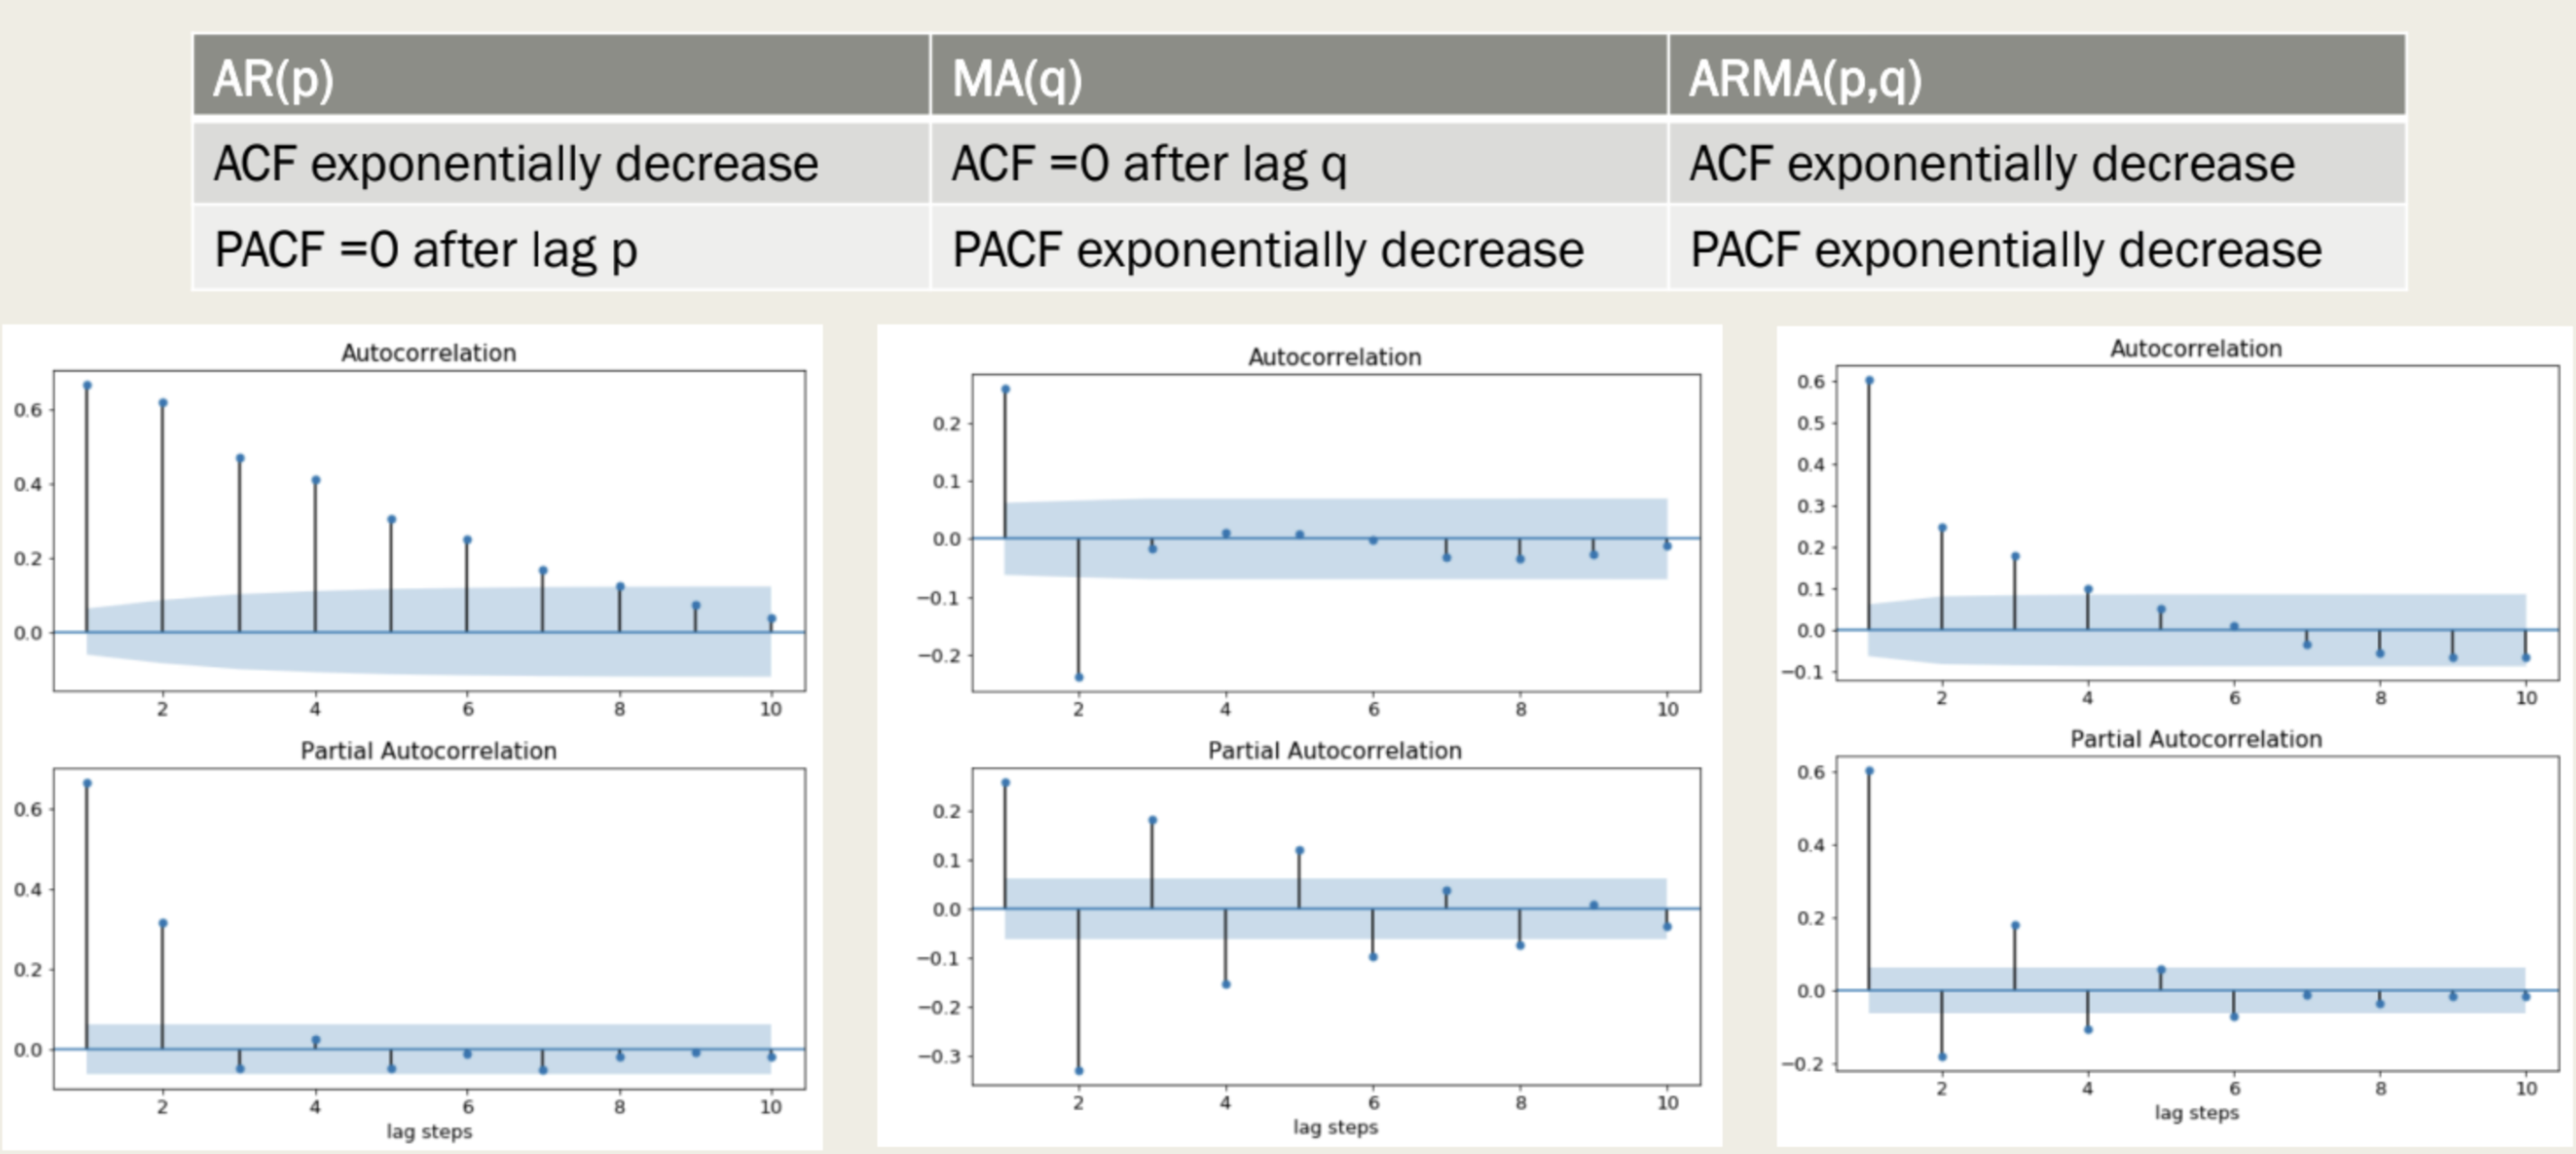

Теперь попробуем определить порядки ARMA.

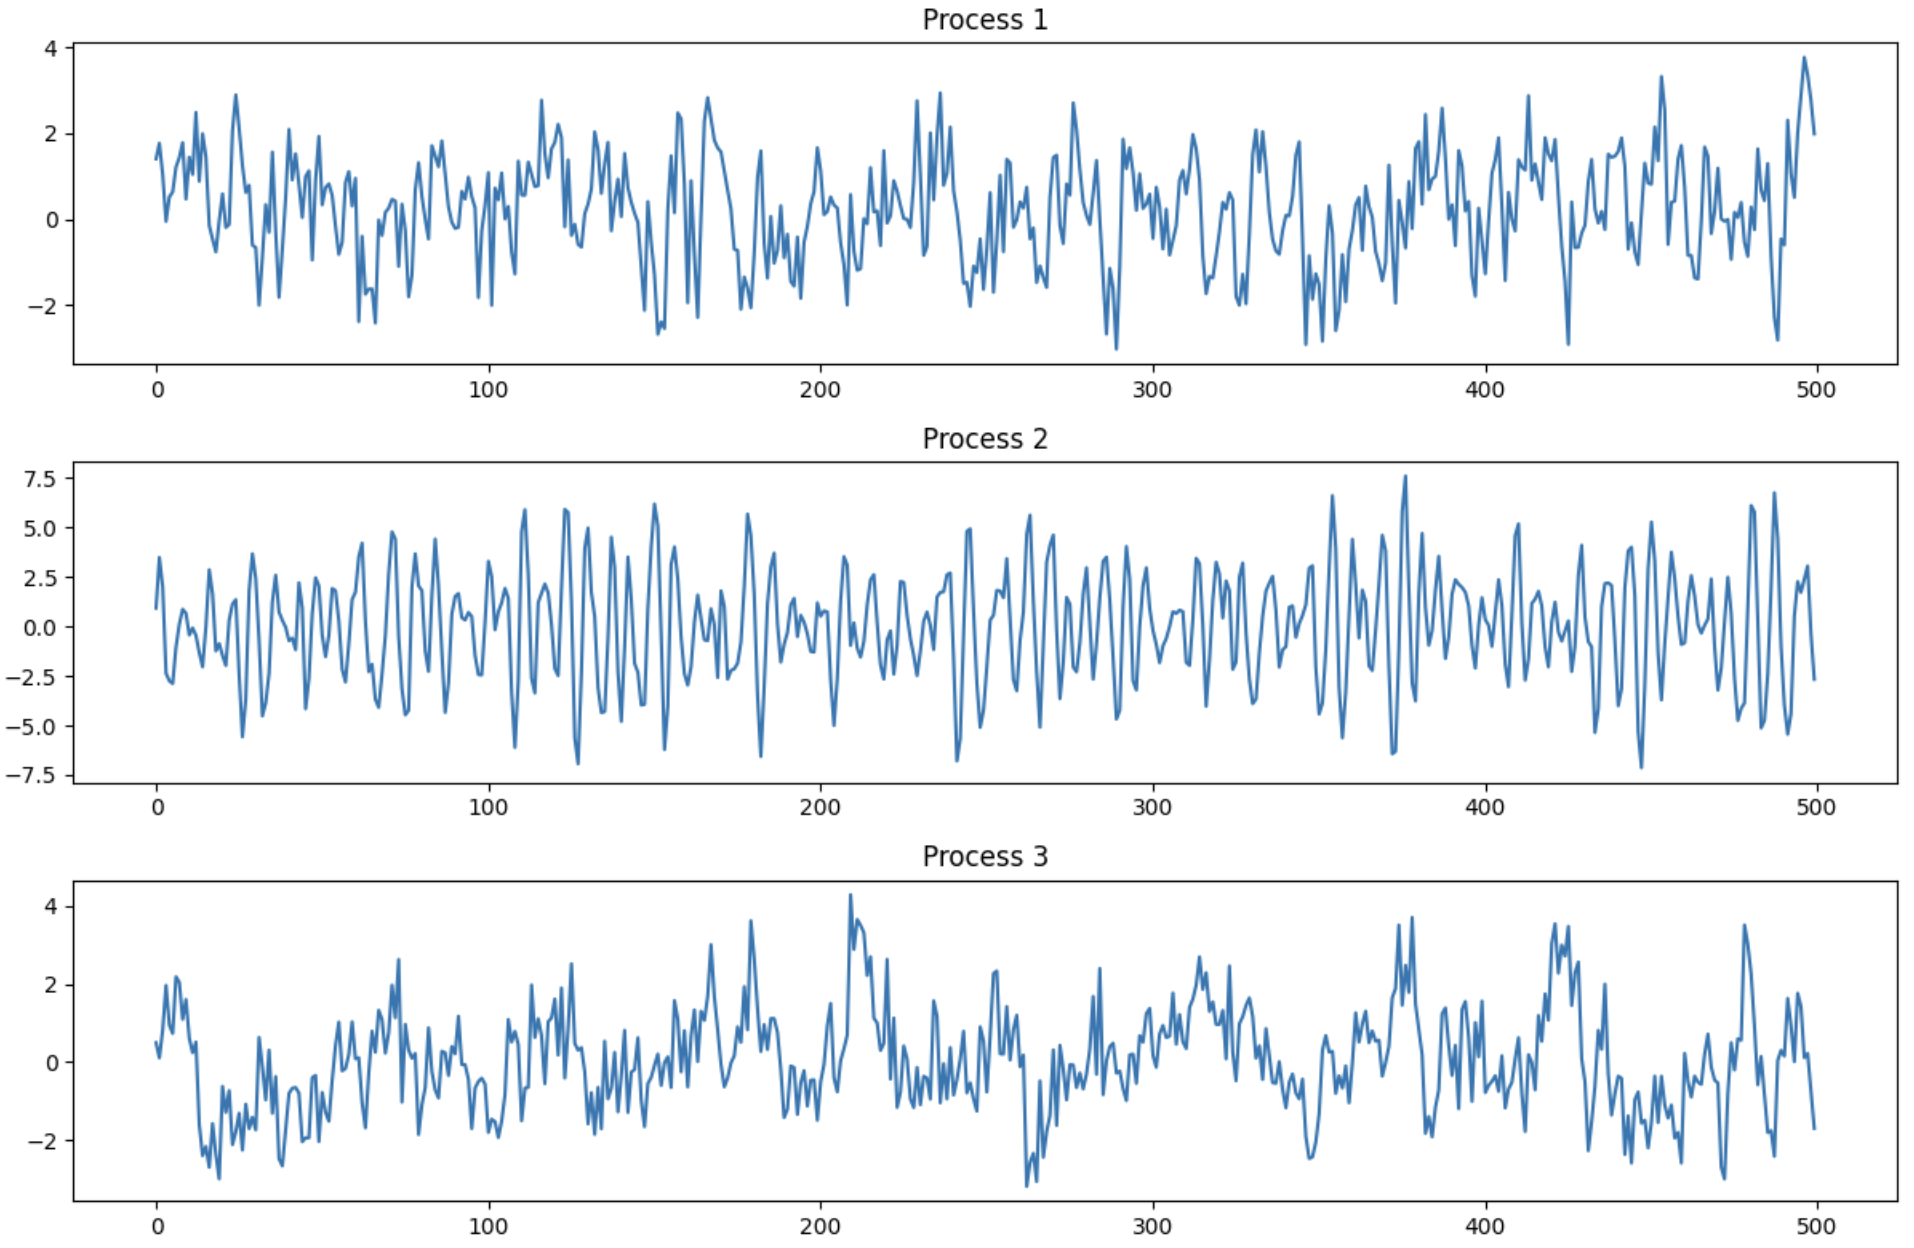

😻 **Посмотрите на функции ACF и PACF и предположите порядки моделей.**

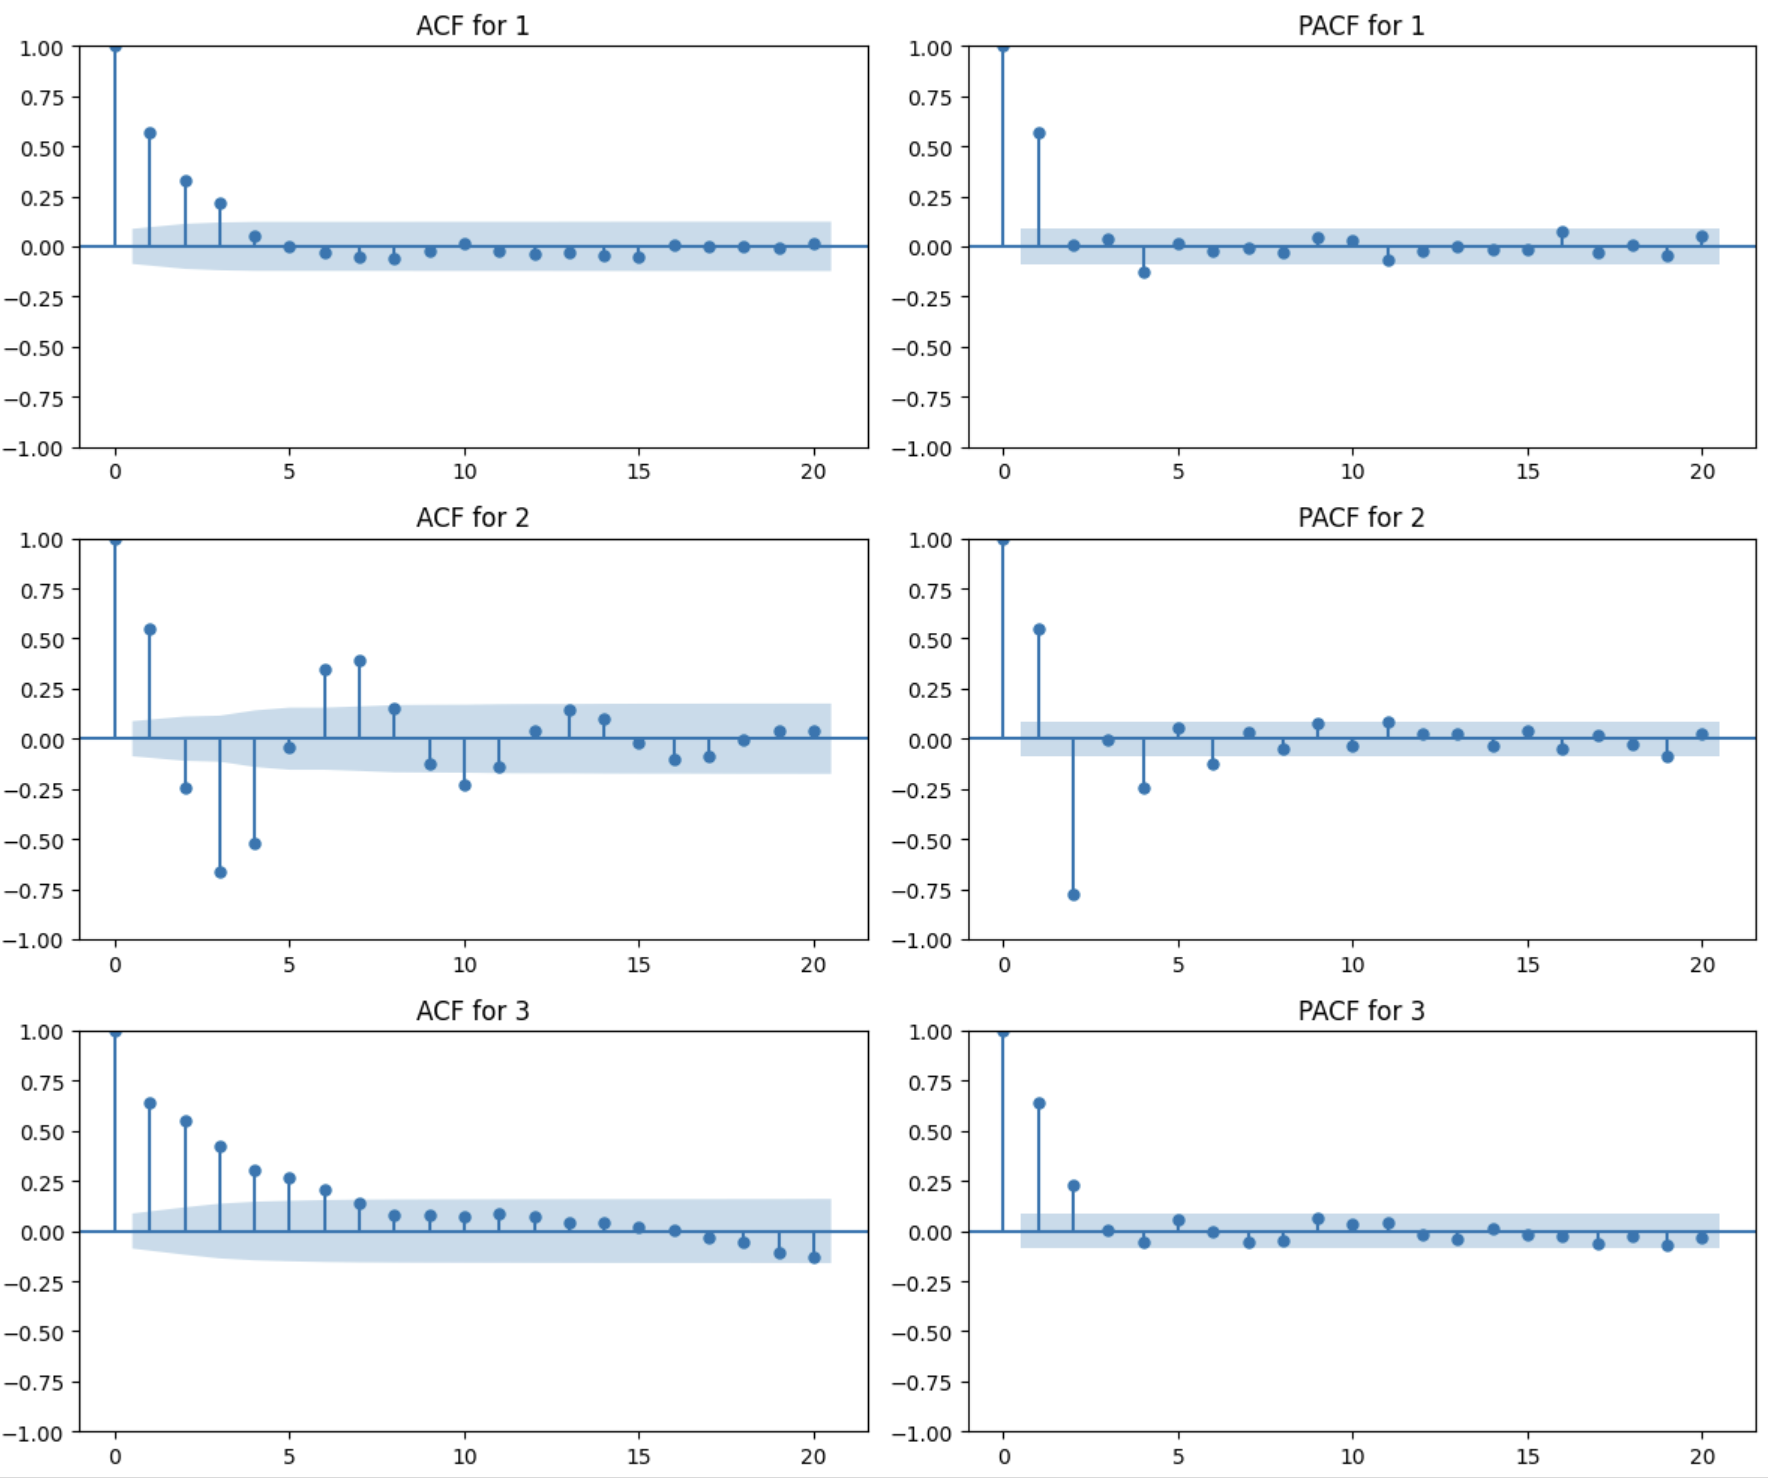

Когда в моделях AR, MA или ARMA присутствуют отрицательные коэффициенты, поведение ACF и PACF меняется особым образом. Поэтому ACF и PACF дают скорее полезные подсказки, чем прямые ответы.

Вернёмся к данным, которые рассматривали в самом начале.

In [ ]:
fig = px.line(ss_df, x=ss_df.index, y=ss_df['y'],
              title="Stationary ts")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="t")
fig.update_yaxes(title_text="y")
fig.show()

Построим **ACF и PACF**, чтобы подобрать подходящую модель ARMA.

In [ ]:
# Два графика рядом
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# ACF
plot_acf(ss_df['y'], ax=ax[0], lags=20)
ax[0].set_title('ACF')

# PACF
plot_pacf(ss_df['y'], ax=ax[1], lags=20)
ax[1].set_title('PACF')

plt.tight_layout()
plt.show()


По графику видно, что можно попробовать модель AR(1) и обучить её на нашем ряде.
Попробуем.

In [ ]:
# Создаём модель
model = ARIMA(ss_df['y'], order=(1,0,0)) # параметры задаются как (p,d,q), где p — AR, q — MA

# Обучаем модель
results = model.fit()


In [ ]:
print(results.summary())

Теперь посмотрим на прогноз.

In [ ]:
forecast = results.predict()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(ss_df['y'],color='red')
plt.plot(forecast,color='blue')
plt.legend(['fact','predict'])
plt.show()

### По критериям AIC и BIC

AIC — это критерий выбора модели, помогающий найти компромисс между качеством описания данных и сложностью модели. BIC похож на AIC, но сильнее штрафует за лишние параметры, поэтому более консервативен при выборе сложных моделей.

AIC и BIC используют только для сравнения моделей, обученных на одних и тех же данных. **Чем меньше значение, тем предпочтительнее модель среди сравниваемых.**


Теперь попробуем выбрать лучшую модель по **AIC**.

In [ ]:
best_params = []
for p in np.arange(0,5): # перебираем порядок p AR-части от 0 до 4
  for q in np.arange(0,5): # перебираем порядок q MA-части от 0 до 4
    model = ARIMA(ss_df['y'], order=(p,0,q)).fit()
    best_params.append({'p':p, 'q':q, 'AIC':model.aic, 'BIC':model.bic})

models = pd.DataFrame(best_params).sort_values(by='AIC')
models.head()


Первая строка таблицы соответствует минимальному AIC. Обучим эту модель.


In [ ]:
p_best, q_best = models.iloc[0][['p', 'q']].astype(int)

# Создаём модель
model = ARIMA(ss_df['y'], order=(p_best,0,q_best))

# Обучаем модель
results = model.fit()


In [ ]:
print(results.summary())

Стоит обратить внимание на незначимые коэффициенты в частях AR и MA: возможно, модель излишне сложна.

В таком случае сравните её с более простой моделью, например AR(1), по AIC/BIC, остаткам и качеству прогноза на отложенной выборке. Одного p-value недостаточно, чтобы выбрать окончательную модель.


In [ ]:
forecast = results.predict()
plt.figure(figsize=(10, 6))
plt.plot(ss_df['y'],color='red')
plt.plot(forecast,color='blue')
plt.legend(['fact','predict'])
plt.show()

*Почему разные модели?*

Различия между выводами по ACF/PACF и выбором модели по AIC возникают из-за разных подходов.

*На что опираться?*

* Начните с простой модели: возьмите AR(1) по ACF/PACF и проверьте её.
* Проверяйте остатки: для AR(1) проанализируйте остатки. Если в них остаётся автокорреляция (видны паттерны на ACF/PACF остатков), AR(1) может быть недостаточно.
* Сравнивайте AIC/BIC только для моделей на одних данных.
* Сравнивайте прогнозы на отложенной выборке: хороший результат на обучающих данных не гарантирует хороший прогноз.


# Приведение к стационарности

Понимание и применение методов приведения к стационарности — ключевой навык в анализе временных рядов. Они помогают преобразовать данные так, чтобы соблюдались предпосылки статистических и ML-моделей, благодаря чему результаты становятся точнее и интерпретируемее.

Будем анализировать цены закрытия акций Microsoft. Источник — [страница исторических данных Nasdaq](https://www.nasdaq.com/market-activity/stocks/msft/historical).

Следующая ячейка обращается к источнику, который использует эта страница, и при каждом запуске загружает последние пять лет вплоть до самой свежей доступной торговой даты. Поэтому число наблюдений и границы периода со временем будут меняться.

(!) Учтите, что из-за этого также могут меняться и дальнейшие выводы.


In [ ]:
end_date = pd.Timestamp.today()
url = f"https://api.nasdaq.com/api/quote/MSFT/historical?assetclass=stocks&fromdate={end_date - pd.DateOffset(years=5):%Y-%m-%d}&todate={end_date:%Y-%m-%d}&limit=5000"
stocks = pd.DataFrame(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).json()["data"]["tradesTable"]["rows"])


In [ ]:
stocks

In [ ]:
stocks.head()

Сделаем небольшую предобработку.

In [ ]:
stocks = stocks.rename(columns={'date': 'ds', 'close': 'y'})
stocks['ds'] = pd.to_datetime(stocks['ds'], format='%m/%d/%Y')
stocks['y'] = (
    stocks['y']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

stocks = stocks[['ds', 'y']].sort_values(by='ds').set_index('ds')


In [ ]:
stocks.head()

Построим график нашего ряда.

In [ ]:
fig = px.line(stocks, x=stocks.index, y=stocks['y'],
              title="Microsoft closing prices (daily)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="closing price")
fig.show()

Попробуем спрогнозировать исходный ряд.

Далее мы намеренно обучим ARMA на исходном нестационарном ряде, чтобы увидеть, почему хороший in-sample-прогноз ещё не означает корректную модель.

In [ ]:
best_params = []
for p in np.arange(0,5): # перебираем порядок p AR-части от 0 до 4
  for q in np.arange(0,5): # перебираем порядок q MA-части от 0 до 4
    model = ARIMA(stocks['y'], order=(p,0,q)).fit()
    best_params.append({'p':p, 'q':q, 'AIC':model.aic, 'BIC':model.bic})

stock_models = pd.DataFrame(best_params).sort_values(by='AIC')
stock_models.head()


😻 **Какие порядки взять для нашей модели ARMA?**

In [ ]:
p_best, q_best = stock_models.iloc[0][['p', 'q']].astype(int)

# Создаём модель
model = ARIMA(stocks['y'], order=(p_best,0,q_best))

# Обучаем модель
results = model.fit()

# In-sample-прогноз
forecast = results.predict()

plt.figure(figsize=(10, 6))
plt.plot(stocks['y'], color='red')
plt.plot(forecast, color='blue')
plt.legend(['fact', 'predict'])
plt.show()


*Почему графики почти совпадают?*

Это in-sample-прогноз: модель предсказывает значения внутри обучающей выборки. Цены акций сильно зависят от недавних значений, поэтому даже простой прогноз, близкий ко вчерашней цене, визуально выглядит хорошо.

Такое совпадение не доказывает, что модель хорошо прогнозирует будущее. Для проверки нужен прогноз на отложенной выборке и сравнение с наивным прогнозом $\hat y_t = y_{t-1}$.

Абсолютное значение AIC не бывает «хорошим» или «плохим»: AIC имеет смысл только при сравнении моделей на одних данных.


Если взглянуть на прогнозы поближе, видно, что результат далёк от идеального.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(stocks['y'].iloc[-50:], color='red') # берём последние 50 наблюдений
plt.plot(forecast.iloc[-50:], color='blue') # берём последние 50 прогнозов
plt.legend(['fact', 'predict'])
plt.show()


## Дифференцирование

**Дифференцирование** — распространённый приём, который часто помогает сделать ряд стационарным за счёт удаления тренда или сезонности. Суть метода — вычитать предыдущее значение из текущего. Для сезонного дифференцирования вычитают значение через сезонный шаг.

Порядок дифференцирования показывает, сколько раз применили операцию. Обычно достаточно первого порядка.

**Формула**

$\Delta Y_t = Y_t - Y_{t-1}$


In [ ]:
stocks['diff'] = stocks['y'].diff()
stocks.head()

In [ ]:
fig = px.line(stocks, x=stocks.index, y=stocks['diff'],
              title="Microsoft closing prices (daily) - diff(1)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="change in closing price")
fig.show()


In [ ]:
adf_test(stocks['diff'].dropna())

Но как обратить преобразование?

In [ ]:
y_0 = stocks['y'].iloc[0] # берём первое значение как начало
stocks['diff'].fillna(0).cumsum() + y_0


Иногда даже после дифференцирования данные не выглядят стационарными, и приходится применять операцию повторно. На практике почти никогда не требуется порядок выше второго.

На следующем занятии повторим приведение к стационарности с помощью дифференцирования и обсудим приёмы процентного изменения и декомпозиции.

# Итоги

* Обсудили ACF и PACF для анализа автокорреляции
* Рассмотрели белый шум и случайное блуждание (с дрейфом и без)
* Сгенерировали процессы ARMA(p,q) и обучили модели ARMA, внимательно анализируя результаты
* Поговорили о выборе порядков ARMA с помощью ACF, PACF и критериев AIC, BIC
* Разобрали дифференцирование для приведения ряда к стационарности. В след. раз обсудим др. способы приведения к стационарности

Пожалуйста, оставьте отзыв [здесь](https://forms.gle/vs3ZZkm9PbktCBt97), чтобы сделать занятия ещё эффективнее :)